# GB Plane Sampling Demo

This notebook demonstrates the first boundary-plane sampling workflows added to byxtal.

The examples use two CSLs:

- `13a`, a small sigma case that is easy to inspect.
- `651a`, a higher sigma case that exercises the same machinery on a denser CSL problem.

For each CSL, the notebook shows two public workflows:

- `search_boundary_plane(...)`: single-target angular search near a grain-1 conventional Miller normal.
- `enumerate_boundary_planes_by_area(...)`: max-area enumeration of CSL-valid boundary-plane records.

The lower-level `generate_normals_by_area(...)` function is still available when you only want the raw CSL reciprocal normal pool.


## Imports

In [1]:
import json
import numpy as np
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

import byxtal.boundary_plane_sampling as bps
import byxtal.csl_utility_functions as cuf
import byxtal.lattice as gbl

## Small Display Helpers

The byxtal functions return plain dict/list records with NumPy arrays. These helpers only format the records for notebook display.

In [2]:
def hkl_str(values):
    arr = np.asarray(values, dtype=int).reshape(-1)
    return "[" + " ".join(f"{value:d}" for value in arr) + "]"


def f3(value):
    if value is None:
        return ""
    return f"{float(value):.3f}"


def markdown_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        lines.append("| " + " | ".join(str(item) for item in row) + " |")
    return "\n".join(lines)


def show_plane_records(title, result, max_rows=10):
    planes = result.get("candidates", result["planes"])
    rows = []
    for rank, candidate in enumerate(planes[:max_rows], start=1):
        rows.append([
            rank,
            hkl_str(candidate["grain1_miller_conventional"]),
            hkl_str(candidate["csl_reciprocal_index"]),
            f3(candidate.get("target_angle_error_deg")),
            f3(candidate["primitive_metrics"]["area"]),
            f3(candidate["best_by_area"]["area"]),
            f3(candidate["best_by_angle_error"]["angle_deg"]),
            f3(candidate["best_by_effective_area"]["effective_area"]),
            candidate.get("source_count", 1),
            len(candidate["pareto_candidates"]),
        ])

    pool_count = len(result.get("all_candidates", result["planes"]))
    source_count = len(result.get("source_candidates", []))
    display(Markdown(f"### {title}"))
    display(Markdown(
        f"Method: `{result['method']}`  \n"
        f"Displayed plane records: `{len(planes)}`  \n"
        f"Candidate pool records: `{pool_count}`  \n"
        f"Source records: `{source_count}`"))
    if not rows:
        display(Markdown("No candidates found with these cutoffs."))
        return

    display(Markdown(markdown_table(
        [
            "rank", "grain-1 hkl", "CSL reciprocal hkl",
            "target error deg", "primitive area", "best area",
            "best angle deg", "best effective area",
            "source count", "Pareto count",
        ],
        rows,
    )))


def show_coverage_diagnostics(title, result):
    diagnostics = result["diagnostics"]
    display(Markdown(f"### {title}"))
    display(Markdown("\n".join([
        f"- selected count: `{diagnostics['selected_count']}`",
        f"- candidate count: `{diagnostics['candidate_count']}`",
        f"- max gap: `{f3(diagnostics['max_gap_deg'])}` deg",
        f"- coverage complete: `{diagnostics['coverage_complete']}`",
        f"- stopped by: `{diagnostics['stopped_by']}`",
    ])))


def show_recommended_details(title, candidate):
    display(Markdown(f"### {title}"))
    display(Markdown(
        "\n".join([
            f"- grain-1 hkl: `{hkl_str(candidate['grain1_miller_conventional'])}`",
            f"- CSL reciprocal hkl: `{hkl_str(candidate['csl_reciprocal_index'])}`",
            f"- target angle error: `{f3(candidate['target_angle_error_deg'])}` deg",
            f"- primitive 2D CSL area: `{f3(candidate['primitive_metrics']['area'])}`",
            f"- best orthogonal/near-orthogonal angle: `{f3(candidate['best_by_angle_error']['angle_deg'])}` deg",
            f"- best effective area: `{f3(candidate['best_by_effective_area']['effective_area'])}`",
            f"- source normals in FZ group: `{candidate.get('source_count', 1)}`",
            f"- Pareto candidate count: `{len(candidate['pareto_candidates'])}`",
        ])
    ))
    print("primitive_basis, columns are the two 2D CSL basis vectors in grain-1 primitive coordinates:")
    print(candidate["primitive_basis"])
    print("\nbest_by_effective_area basis:")
    print(candidate["best_by_effective_area"]["basis"])


## Build CSL Records

`csl_record_from_sig_id(...)` returns one sorted CSL variant, such as `13a` or `651a`, in the record shape expected by `search_boundary_plane(...)`. If you already have `enumerate_csl_props(...)` output, use `csl_record_from_props(...)` to extract one record from it.

In [3]:
lat_type = gbl.Lattice()  # default is cF_Id

record_13a = cuf.csl_record_from_sig_id("13a", "common", lat_type)

record_651a = cuf.csl_record_from_sig_id("651a", "common", lat_type)

target_miller = [1, 1, 1]

## Sigma 13a: Angular Search

This is the public single-target search. It finds CSL reciprocal normals within an angular radius of the target grain-1 conventional Miller normal, computes 2D CSL bases, searches small supercells, maps normals into the boundary-plane FZ, and ranks the FZ-group representative records.

In [4]:
result_13a = bps.search_boundary_plane(
    record_13a,
    lat_type,
    target_miller,
    max_area=8.0,
    angle_radius_deg=25.0,
    max_transform_index=1,
    max_area_multiplier=4,
    n_results=10,
)

show_plane_records("Sigma 13a angular search near [1 1 1]", result_13a)


### Sigma 13a angular search near [1 1 1]

Method: `target_search`  
Displayed plane records: `5`  
Candidate pool records: `5`  
Source records: `7`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [1 1 1] | [1 3 -1] | 0.000 | 5.629 | 5.629 | 102.520 | 1.077 | 2 | 16 |
| 2 | [13 17 19] | [1 4 -1] | 8.683 | 7.155 | 7.155 | 76.255 | 1.093 | 2 | 32 |
| 3 | [13 23 15] | [1 4 -2] | 14.260 | 7.595 | 7.595 | 88.115 | 1.002 | 1 | 8 |
| 4 | [13 9 7] | [1 2 -1] | 14.469 | 4.323 | 4.323 | 99.843 | 1.048 | 1 | 8 |
| 5 | [13 19 9] | [1 3 -2] | 16.736 | 6.180 | 6.180 | 99.192 | 1.123 | 1 | 16 |

## Sigma 13a: Max-Area Plane Enumeration

`enumerate_boundary_planes_by_area(...)` starts from the max-area CSL reciprocal normal pool, evaluates each normal into the same plane-record structure used by angular search, and keeps per-plane `cell_options` plus `pareto_candidates`.


In [5]:
result_13a_area = bps.enumerate_boundary_planes_by_area(
    record_13a,
    lat_type,
    max_area=16.0,
    max_transform_index=1,
    max_area_multiplier=4,
)

show_plane_records("Sigma 13a max-area plane records", result_13a_area)

raw_normals_13a = bps.generate_normals_by_area(
    record_13a["csl_mat"],
    lat_type.l_p_po,
    max_area=16.0,
)
display(Markdown(
    f"Raw normals from `generate_normals_by_area(...)`: `{len(raw_normals_13a)}`"))


### Sigma 13a max-area plane records

Method: `max_area`  
Displayed plane records: `109`  
Candidate pool records: `109`  
Source records: `685`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [0 5 1] | [0 1 -1] |  | 2.550 | 2.550 | 90.000 | 1.000 | 2 | 16 |
| 2 | [0 11 -3] | [0 1 -3] |  | 5.701 | 5.701 | 90.000 | 1.000 | 4 | 32 |
| 3 | [1 0 0] | [2 1 -1] |  | 6.500 | 6.500 | 90.000 | 1.000 | 1 | 8 |
| 4 | [13 -2 -3] | [2 0 -1] |  | 6.745 | 6.745 | 90.000 | 1.000 | 4 | 32 |
| 5 | [13 2 -10] | [2 -1 -3] |  | 8.261 | 8.261 | 90.000 | 1.000 | 4 | 32 |
| 6 | [13 -6 -9] | [2 -2 -1] |  | 8.456 | 8.456 | 90.000 | 1.000 | 4 | 32 |
| 7 | [0 17 -7] | [0 1 -5] |  | 9.192 | 9.192 | 90.000 | 1.000 | 4 | 32 |
| 8 | [0 21 -1] | [0 3 -5] |  | 10.512 | 10.512 | 90.000 | 1.000 | 4 | 32 |
| 9 | [13 -10 -15] | [2 -4 -1] |  | 11.113 | 11.113 | 90.000 | 1.000 | 4 | 32 |
| 10 | [13 4 -20] | [2 -3 -5] |  | 12.093 | 12.093 | 90.000 | 1.000 | 4 | 32 |

Raw normals from `generate_normals_by_area(...)`: `685`

## Sigma 651a: Angular Search

The same public search can be used for a higher sigma CSL. Here the area cutoff is larger because the primitive 2D CSL areas are naturally larger for this case.

In [6]:
result_651a = bps.search_boundary_plane(
    record_651a,
    lat_type,
    target_miller,
    max_area=100.0,
    angle_radius_deg=5.0,
    max_transform_index=1,
    max_area_multiplier=4,
    n_results=10,
)

show_plane_records("Sigma 651a angular search near [1 1 1]", result_651a)


### Sigma 651a angular search near [1 1 1]

Method: `target_search`  
Displayed plane records: `1`  
Candidate pool records: `1`  
Source records: `1`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [1 1 1] | [0 1 0] | 0.000 | 93.964 | 93.964 | 90.000 | 1.444 | 1 | 32 |

## Sigma 651a: Max-Area Plane Enumeration

The high-sigma max-area enumeration is useful for seeing how many CSL-valid plane records are available before adding target-direction or FZ coverage selection.


In [7]:
result_651a_area = bps.enumerate_boundary_planes_by_area(
    record_651a,
    lat_type,
    max_area=200.0,
    max_transform_index=1,
    max_area_multiplier=4,
)

show_plane_records("Sigma 651a max-area plane records", result_651a_area)

raw_normals_651a = bps.generate_normals_by_area(
    record_651a["csl_mat"],
    lat_type.l_p_po,
    max_area=200.0,
)
display(Markdown(
    f"Raw normals from `generate_normals_by_area(...)`: `{len(raw_normals_651a)}`"))


### Sigma 651a max-area plane records

Method: `max_area`  
Displayed plane records: `117`  
Candidate pool records: `117`  
Source records: `523`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [1 -26 25] | [0 0 1] |  | 18.042 | 18.042 | 90.000 | 1.000 | 3 | 24 |
| 2 | [8 9 -17] | [1 0 -1] |  | 31.249 | 31.249 | 90.000 | 1.000 | 2 | 16 |
| 3 | [17 -8 -9] | [2 0 1] |  | 31.249 | 31.249 | 90.000 | 1.000 | 1 | 8 |
| 4 | [23 53 -76] | [1 0 -2] |  | 47.734 | 47.734 | 90.000 | 1.000 | 3 | 24 |
| 5 | [4 -11 7] | [1 0 3] |  | 47.734 | 47.734 | 90.000 | 1.000 | 3 | 24 |
| 6 | [22 79 -101] | [1 0 -3] |  | 65.050 | 65.050 | 90.000 | 1.000 | 3 | 24 |
| 7 | [29 -103 74] | [1 0 4] |  | 65.050 | 65.050 | 90.000 | 1.000 | 3 | 24 |
| 8 | [47 80 -127] | [2 0 -3] |  | 78.642 | 78.642 | 90.000 | 1.000 | 3 | 24 |
| 9 | [55 -128 73] | [2 0 5] |  | 78.642 | 78.642 | 90.000 | 1.000 | 3 | 24 |
| 10 | [1 5 -6] | [1 0 -4] |  | 82.677 | 82.677 | 90.000 | 1.000 | 3 | 24 |

Raw normals from `generate_normals_by_area(...)`: `523`

## Plot Pareto Fronts

Pareto dominance here is for the cell options of one plane record. It uses only `area` and `angle_error_deg`: a cell option is dominated if another option has no larger area, no larger angle error, and is strictly better in at least one of those two metrics. `aspect_ratio` is still reported, but it does not determine the Pareto front.

The plots below show all searched cell options for the recommended angular-search plane records and highlight the Pareto front. Color shows the per-plane dimensionless `effective_area = (1 + (angle_error_deg/45)^2) * area/min_area` diagnostic.


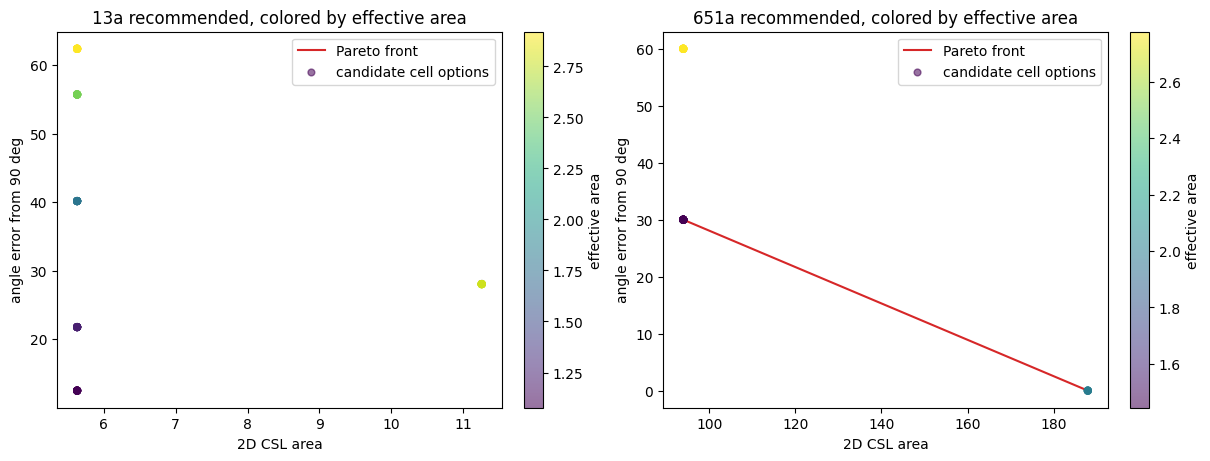

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

bps.plot_pareto_front(
    result_13a["recommended"],
    ax=axes[0],
    color_by="effective_area",
    title="13a recommended, colored by effective area",
)
bps.plot_pareto_front(
    result_651a["recommended"],
    ax=axes[1],
    color_by="effective_area",
    title="651a recommended, colored by effective area",
);


## Parameters Worth Tuning

- `max_area` controls how large the primitive 2D CSL candidates are allowed to be.
- `angle_radius_deg` controls how far from the target plane normal the angular search may look.
- `max_transform_index` controls the integer entries used in the small `2x2` supercell search.
- `max_area_multiplier` controls the maximum area multiple allowed for supercell options.

For exploratory work, start with small `max_transform_index` and `max_area_multiplier` values, then increase them only when you need to look for better orthogonality or better balanced cell shapes.

## Inspect Recommended Candidates

The returned candidate records keep both summary metrics and the actual basis matrices. The columns of each basis matrix are the two in-plane 2D CSL basis vectors in grain-1 primitive coordinates.

In [9]:
show_recommended_details("Recommended sigma 13a candidate", result_13a["recommended"])
show_recommended_details("Recommended sigma 651a candidate", result_651a["recommended"])

### Recommended sigma 13a candidate

- grain-1 hkl: `[1 1 1]`
- CSL reciprocal hkl: `[1 3 -1]`
- target angle error: `0.000` deg
- primitive 2D CSL area: `5.629`
- best orthogonal/near-orthogonal angle: `102.520` deg
- best effective area: `1.077`
- source normals in FZ group: `2`
- Pareto candidate count: `16`

primitive_basis, columns are the two 2D CSL basis vectors in grain-1 primitive coordinates:
[[-1.  5.]
 [ 3. -2.]
 [-2. -3.]]

best_by_effective_area basis:
[[ 1. -5.]
 [-3.  2.]
 [ 2.  3.]]


### Recommended sigma 651a candidate

- grain-1 hkl: `[1 1 1]`
- CSL reciprocal hkl: `[0 1 0]`
- target angle error: `0.000` deg
- primitive 2D CSL area: `93.964`
- best orthogonal/near-orthogonal angle: `90.000` deg
- best effective area: `1.444`
- source normals in FZ group: `1`
- Pareto candidate count: `32`

primitive_basis, columns are the two 2D CSL basis vectors in grain-1 primitive coordinates:
[[  9.  17.]
 [-17.  -8.]
 [  8.  -9.]]

best_by_effective_area basis:
[[-9. 17.]
 [17. -8.]
 [-8. -9.]]


## Plot Max-Area FZ Overviews

These overview plots compare different plane directions. Marker size is based on a plot-level effective area normalized by the minimum selected-cell area across the displayed planes, so larger circles indicate more practical selected cells for that plotted set.


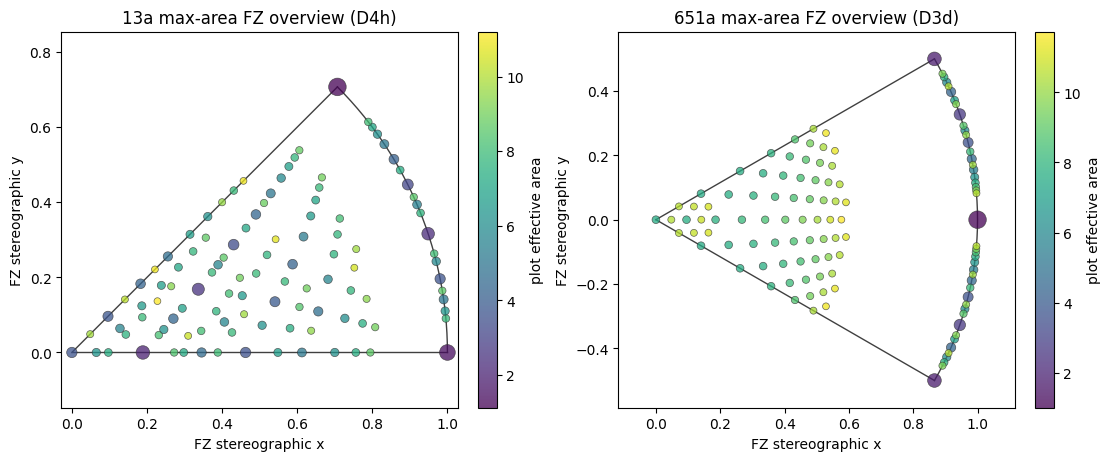

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

bps.plot_boundary_plane_fz(
    result_13a_area,
    ax=axes[0],
    title="13a max-area FZ overview",
)
bps.plot_boundary_plane_fz(
    result_651a_area,
    ax=axes[1],
    title="651a max-area FZ overview",
);


## Quality-Ordered FZ Spacing Selection

`sample_boundary_plane_fz(...)` operates on an existing plane-record result, such as `enumerate_boundary_planes_by_area(...)`. It walks the candidate pool from best to worst practical cell quality, adds a plane only when it is at least `min_spacing_deg` from the selected set, and can stop early once every candidate-pool direction is within `max_spacing_deg` of a selected plane.


In [11]:
coverage_13a = bps.sample_boundary_plane_fz(
    result_13a_area,
    min_spacing_deg=8.0,
    max_spacing_deg=1.0,
)
coverage_651a = bps.sample_boundary_plane_fz(
    result_651a_area,
    min_spacing_deg=5.0,
    max_spacing_deg=18.0,
)

show_plane_records("Sigma 13a quality-ordered FZ spacing", coverage_13a)
show_coverage_diagnostics("Sigma 13a spacing diagnostics", coverage_13a)

show_plane_records("Sigma 651a quality-ordered FZ spacing", coverage_651a)
show_coverage_diagnostics("Sigma 651a spacing diagnostics", coverage_651a)


### Sigma 13a quality-ordered FZ spacing

Method: `fz_quality_spacing`  
Displayed plane records: `31`  
Candidate pool records: `109`  
Source records: `685`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [0 3 -2] | [0 0 1] |  | 1.803 | 1.803 | 74.499 | 1.119 | 2 | 32 |
| 2 | [0 5 1] | [0 1 -1] |  | 2.550 | 2.550 | 90.000 | 1.000 | 2 | 16 |
| 3 | [13 1 -5] | [1 0 -1] |  | 3.491 | 3.491 | 90.000 | 1.008 | 4 | 64 |
| 4 | [0 8 -1] | [0 1 -2] |  | 4.031 | 4.031 | 82.929 | 1.025 | 4 | 64 |
| 5 | [13 -3 -11] | [1 -1 -1] |  | 4.323 | 4.323 | 80.157 | 1.048 | 8 | 64 |
| 6 | [0 11 -3] | [0 1 -3] |  | 5.701 | 5.701 | 90.000 | 1.000 | 4 | 32 |
| 7 | [13 -7 -17] | [1 -2 -1] |  | 5.629 | 5.629 | 77.480 | 1.077 | 8 | 64 |
| 8 | [13 3 -15] | [1 -1 -2] |  | 5.019 | 5.019 | 90.000 | 1.288 | 4 | 48 |
| 9 | [1 0 0] | [2 1 -1] |  | 6.500 | 6.500 | 90.000 | 1.000 | 1 | 8 |
| 10 | [13 -2 -3] | [2 0 -1] |  | 6.745 | 6.745 | 90.000 | 1.000 | 4 | 32 |

### Sigma 13a spacing diagnostics

- selected count: `31`
- candidate count: `109`
- max gap: `7.829` deg
- coverage complete: `False`
- stopped by: `candidate_pool_exhausted`

### Sigma 651a quality-ordered FZ spacing

Method: `fz_quality_spacing`  
Displayed plane records: `29`  
Candidate pool records: `117`  
Source records: `523`

| rank | grain-1 hkl | CSL reciprocal hkl | target error deg | primitive area | best area | best angle deg | best effective area | source count | Pareto count |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | [1 -26 25] | [0 0 1] |  | 18.042 | 18.042 | 90.000 | 1.000 | 3 | 24 |
| 2 | [8 9 -17] | [1 0 -1] |  | 31.249 | 31.249 | 90.000 | 1.000 | 2 | 16 |
| 3 | [23 53 -76] | [1 0 -2] |  | 47.734 | 47.734 | 90.000 | 1.000 | 3 | 24 |
| 4 | [22 79 -101] | [1 0 -3] |  | 65.050 | 65.050 | 90.000 | 1.000 | 3 | 24 |
| 5 | [19 157 -176] | [1 0 -6] |  | 118.307 | 118.307 | 90.000 | 1.000 | 3 | 24 |
| 6 | [265 271 115] | [1 -1 -1] |  | 99.024 | 99.024 | 90.000 | 1.370 | 3 | 48 |
| 7 | [169 163 319] | [1 1 -1] |  | 99.024 | 99.024 | 90.000 | 1.370 | 3 | 48 |
| 8 | [1 1 1] | [0 1 0] |  | 93.964 | 93.964 | 90.000 | 1.444 | 1 | 32 |
| 9 | [313 325 13] | [2 -1 -2] |  | 112.850 | 112.850 | 90.000 | 1.208 | 3 | 48 |
| 10 | [121 109 421] | [2 1 -2] |  | 112.850 | 112.850 | 90.000 | 1.208 | 3 | 48 |

### Sigma 651a spacing diagnostics

- selected count: `29`
- candidate count: `117`
- max gap: `16.378` deg
- coverage complete: `True`
- stopped by: `max_spacing_met`

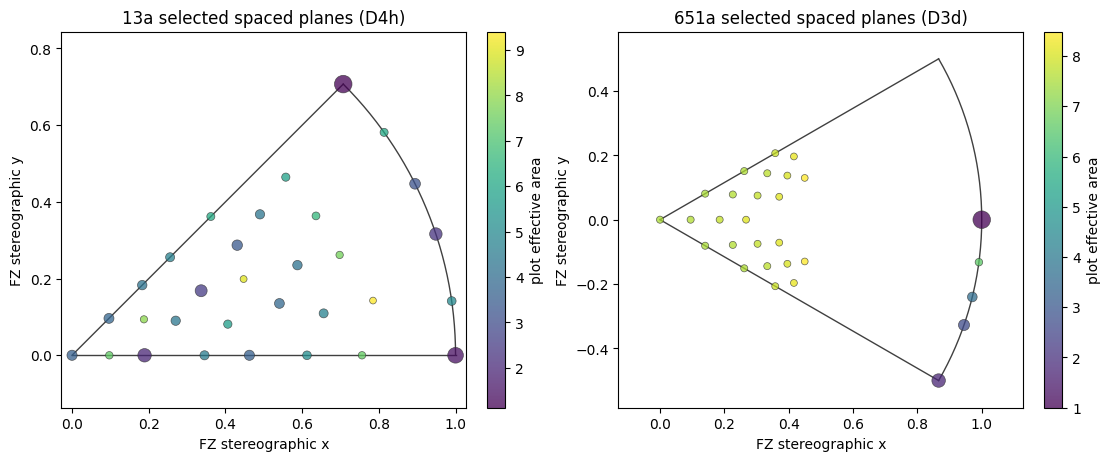

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

bps.plot_boundary_plane_fz(
    coverage_13a,
    ax=axes[0],
    title="13a selected spaced planes",
)
bps.plot_boundary_plane_fz(
    coverage_651a,
    ax=axes[1],
    title="651a selected spaced planes",
);


## Full CSL Cell

`calculate_csl_cell(...)` completes the selected 2D CSL boundary-plane basis with a third CSL vector. This creates a periodic 3D CSL cell that can be used for orientation-cell checks before building bicrystal slabs.

In [13]:
selected_plane_13a = result_13a["recommended"]

csl_cell_13a = bps.calculate_csl_cell(
    selected_plane_13a,
    record_13a,
    lat_type,
    completion_search_radius=4,
    completion_strategy="balanced_orthogonality_volume",
)

completion = csl_cell_13a["completion_vector"]
volume_in_primitive_lattice_cells = (
    csl_cell_13a["volume"] / csl_cell_13a["primitive_lattice_volume"]
)

display(Markdown("### Full CSL cell for recommended Sigma 13a plane"))
display(Markdown(markdown_table(
    ["quantity", "value"],
    [
        ["Sigma from primitive CSL volume", f3(csl_cell_13a["sigma_from_csl_volume"])],
        ["3D cell volume / primitive lattice volume", f3(volume_in_primitive_lattice_cells)],
        ["3D cell volume / primitive CSL volume", f3(csl_cell_13a["volume_multiplier_over_primitive_csl"])],
        ["completion strategy requested", f"`{completion['selection_strategy']}`"],
        ["completion strategy used", f"`{completion['strategy_used']}`"],
        ["third-vector angle to BP normal deg", f3(completion["angle_to_plane_normal_deg"])],
        ["candidate count", completion["candidate_count"]],
    ],
)))

print("basis_grain1_primitive, columns are the completed 3D CSL basis:")
print(np.asarray(csl_cell_13a["basis_grain1_primitive"], dtype=int))
print("\nbasis_grain2_primitive:")
print(np.asarray(csl_cell_13a["basis_grain2_primitive"], dtype=int))
print("\nbasis_cartesian:")
print(np.asarray(csl_cell_13a["basis_cartesian"], dtype=float))

### Full CSL cell for recommended Sigma 13a plane

| quantity | value |
| --- | --- |
| Sigma from primitive CSL volume | 13.000 |
| 3D cell volume / primitive lattice volume | 13.000 |
| 3D cell volume / primitive CSL volume | 1.000 |
| completion strategy requested | `balanced_orthogonality_volume` |
| completion strategy used | `balanced_orthogonality_volume` |
| third-vector angle to BP normal deg | 35.264 |
| candidate count | 702 |

basis_grain1_primitive, columns are the completed 3D CSL basis:
[[ 1 -5  0]
 [-3  2  0]
 [ 2  3 -1]]

basis_grain2_primitive:
[[  0  -5   3]
 [ -3   3   2]
 [  2   2 -15]]

basis_cartesian:
[[-0.5  2.5 -0.5]
 [ 1.5 -1.  -0.5]
 [-1.  -1.5  0. ]]


## BoundaryPlaneRecord Export

Once a plane is picked and everything is calculated, one can export a `BoundaryPlaneRecord` using the `export_boundary_plane_record(...)` function. This takes the selected plane, CSL record, lattice, and precomputed CSL-cell calculation and returns the JSON-like `BoundaryPlaneRecord` shape intended for downstream atomistic workflows.

In [14]:
boundary_plane_record_13a = bps.export_boundary_plane_record(
    selected_plane_13a,
    record_13a,
    lat_type,
    csl_cell_13a,
)

display(Markdown("### BoundaryPlaneRecord JSON-like export"))
display(Markdown("\n".join([
    f"- record type: `{boundary_plane_record_13a['record_type']}`",
    f"- Sigma ID: `{boundary_plane_record_13a['sig_id']}`",
    f"- grain-1 Miller normal: `{hkl_str(boundary_plane_record_13a['plane_normals']['grain1_miller'])}`",
    f"- grain-2 Miller normal: `{hkl_str(boundary_plane_record_13a['plane_normals']['grain2_miller'])}`",
    f"- BP FZ grain-1 Miller normal: `{hkl_str(boundary_plane_record_13a['plane_normals']['bp_fz_miller_grain1'])}`",
    f"- BP 2D CSL area: `{f3(boundary_plane_record_13a['bp_2d_csl_cell']['area'])}`",
])))

print(json.dumps(boundary_plane_record_13a, indent=2))

### BoundaryPlaneRecord JSON-like export

- record type: `boundary_plane`
- Sigma ID: `13a`
- grain-1 Miller normal: `[1 1 1]`
- grain-2 Miller normal: `[-13 -17 -7]`
- BP FZ grain-1 Miller normal: `[1 -1 1]`
- BP 2D CSL area: `5.629`

{
  "record_type": "boundary_plane",
  "sig_id": "13a",
  "csl_rotation_id": "13_2",
  "lattice_type": "cF_Id",
  "plane_normals": {
    "grain1_miller": [
      1,
      1,
      1
    ],
    "grain2_miller": [
      -13,
      -17,
      -7
    ],
    "bp_fz_miller_grain1": [
      1,
      -1,
      1
    ],
    "bp_fz_miller_grain2": [
      -13,
      7,
      -17
    ],
    "bp_fz_normal_grain1_po": [
      0.577350269189626,
      -0.5773502691896255,
      0.5773502691896258
    ],
    "bp_fz_normal_grain2_po": [
      -0.5773502691896262,
      0.3108809141790287,
      -0.7549965058633568
    ],
    "bp_fz_normal_grain1_sg": [
      0.6793662204867573,
      0.4529108136578379,
      0.5773502691896258
    ],
    "bp_fz_stereographic_xy_grain1_sg": [
      0.430700925315584,
      0.2871339502103892
    ],
    "basis_convention": "column_vectors"
  },
  "bp_2d_csl_cell": {
    "basis_convention": "column_vectors",
    "basis_grain1_primitive": [
      [
        1,
        -5
